# Approximators

An **approximator** is the central object in BayesFlow. It wires together an adapter, an optional [summary network](./summary_networks.ipynb), and an [inference network](./inference_networks.ipynb), and exposes a unified API for training and inference.

Approximators are Keras models. They implement `.fit()` for training and task-specific inference methods (`.sample()`, `.log_prob()`, `.predict()`, etc.) for posterior queries.

This page covers:

1. [Approximator types](#approximator-types) — which one to use for your task
2. [Key methods](#key-methods) — `fit`, `sample`, `log_prob`, and friends
3. [Standalone training](#standalone-training) — using approximators without a workflow

## Approximator Types

Approximators are independent Keras models — you don't need a workflow to use them, even though workflows are recommended unless you need lower level control. This is useful when you want fine-grained control over the training loop, want to integrate BayesFlow into an existing codebase, or are building a non-standard pipeline.

| Approximator | Task | Primary inference method |
|---|---|---|
| `ContinuousApproximator` | Neural posterior / likelihood estimation (NPE, NLE) | `.sample()`, `.log_prob()` |
| `ModelComparisonApproximator` | Bayesian model selection (discrete posteriors) | `.predict()` |
| `RatioApproximator` | Likelihood-to-evidence ratio estimation (NRE-C) | `.log_ratio()` |
| `ScoringRuleApproximator` | Point estimation via scoring-rule minimization | `.estimate()` |
| `EnsembleApproximator` | Ensemble of heterogeneous approximators | `.sample()`, `.log_prob()`, `.estimate()` |
| `CompositionalApproximator` | Compositional / hierarchical distributions | `.compositional_sample()` |

All approximators live in `bayesflow.approximators` and are re-exported from the top-level `bayesflow` namespace.

In [ ]:
import bayesflow as bf

## Key Methods

### `fit` and `compile`

All approximators share the same `fit` interface. You can pass either a simulator (BayesFlow builds the dataset for you) or a pre-built dataset:



In [2]:
# Here's a very basic simulator and adapter
import numpy as np

def prior():
    return dict(theta=np.random.normal(size=2))

def likelihood(theta):
    return dict(x=np.random.normal(theta[0], np.exp(theta[1] * 0.5), size=20))

simulator = bf.make_simulator([prior, likelihood])

adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .rename("x", "inference_conditions")
    .rename("theta", "inference_variables")
)

In [ ]:
# Create an approximator (e.g., for a continuous distribution)
approximator = bf.ContinuousApproximator(inference_network=bf.networks.FlowMatching(), adapter=adapter)

# Compile first — sets the optimizer; compatible with any keras optimizer
approximator.compile(optimizer="adam")

# Train via simulator (most common path)
history = approximator.fit(simulator=simulator, epochs=10, batch_size=32, num_batches=10, workers=8)

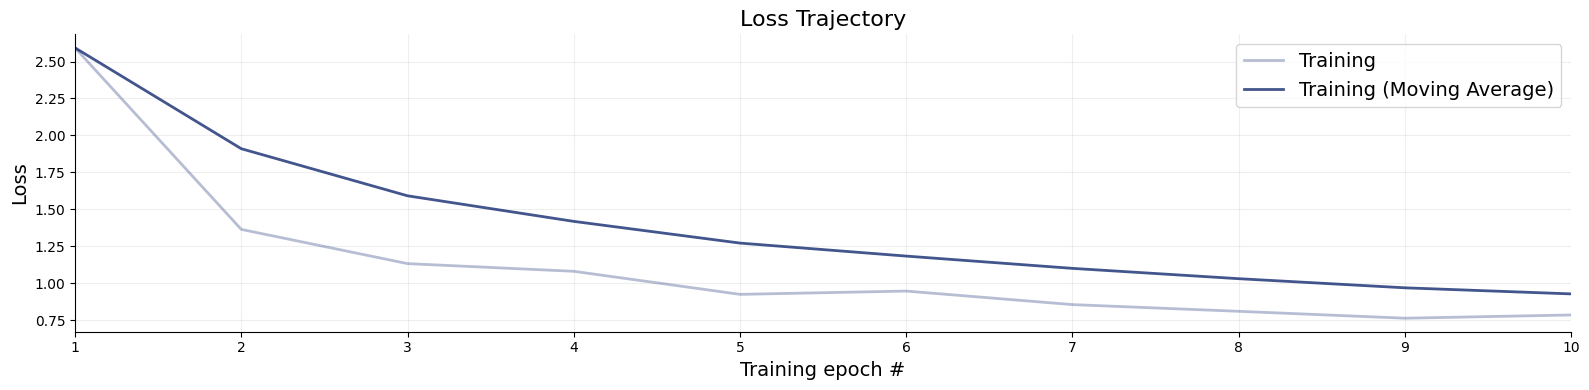

In [4]:
# Loss trajectories can be inspected like so:
f = bf.diagnostics.loss(history)

In [ ]:
# Or using an in-memory simulation bank
sim_bank = simulator.sample(1024)

# Convert simulation bank to a dataset object that takes care of batching etc
dataset = bf.OfflineDataset(sim_bank, batch_size=32, adapter=adapter)

# Training is much faster now, since simulation is decoupled from learning
history = approximator.fit(dataset=dataset, epochs=10)

## ContinuousApproximator

The `ContinuousApproximator` is the standard choice for **neural posterior estimation (NPE)** and **neural likelihood estimation (NLE)**. It learns a continuous density $p(\theta \mid x)$ (or $p(x \mid \theta)$) using a normalizing flow or diffusion-based inference network.



In [ ]:
approximator = bf.approximators.ContinuousApproximator(
    inference_network=bf.networks.FlowMatching(),
    # summary_network=bf.networks.SetTransformer(),  # optional; requires .as_set() in adapter
    adapter=adapter
)
approximator.compile(optimizer="adam")
approximator.fit(simulator=simulator, epochs=2, batch_size=32, num_batches=10)

test_batch = simulator.sample(4)
x_obs = test_batch["x"].astype("float32")
theta = test_batch["theta"].astype("float32")


### `.sample(num_samples, conditions)` — draw posterior samples



In [ ]:
# conditions: dict of observed data, preprocessed by the adapter
samples = approximator.sample(num_samples=1000, conditions={"x": x_obs})
# returns: {"theta": np.ndarray of shape (num_conditions, 1000, theta_dim)}

### `.log_prob(data)` — evaluate the log-posterior density

In [ ]:
log_p = approximator.log_prob({"x": x_obs, "theta": theta})
# returns: np.ndarray of shape (num_conditions,)


### `.ancestral_sample(conditions, ancestral_conditions)` — hierarchical sampling

For hierarchical models, child-level observations are conditioned on parent-level parameters. One can use `ancestral_sample` to specify `child_conditions` and `parent_conditions` correspondingly. See also [our example notebook for compositional diffusion](../../../examples/Compositional_Diffusion.ipynb) for more detail.

In [ ]:
# Example of specifying child and parent (ancestral) conditions for hierarchical sampling
# Not run here because we do not have a hierarchical simulator
# samples = approximator.ancestral_sample( 
#     conditions=child_conditions,
#     ancestral_conditions=parent_conditions,
#     num_samples=500
# )


> **NPE vs NLE:** The choice between posterior estimation and likelihood estimation is controlled entirely by how the adapter routes variables — not by the approximator class. Point `inference_variables` at `theta` for NPE, or at `x` for NLE.

## ModelComparisonApproximator

Use this when comparing a discrete set of competing simulators / models. It learns posterior model probabilities $p(M_k \mid x)$ via a classifier trained with cross-entropy.



In [ ]:
def prior_null(): return dict(mu=0.0)
def prior_alt1(): return dict(mu=np.random.normal(0, 1))
def prior_alt2(): return dict(mu=np.random.normal(0, 2))
def likelihood_mc(mu, n=10): return dict(x=np.random.normal(mu, 1, size=n))

sim1 = bf.make_simulator([prior_null, likelihood_mc])
sim2 = bf.make_simulator([prior_alt1, likelihood_mc])
sim3 = bf.make_simulator([prior_alt2, likelihood_mc])

mc_adapter = (
    bf.Adapter()
    .as_set("x")
    .convert_dtype("float64", "float32")
    .rename("x", "summary_variables")
    .rename("model_indices", "inference_variables")
)

test_batch_mc = bf.simulators.ModelComparisonSimulator([sim1, sim2, sim3]).sample(4)
x_obs_mc = test_batch_mc["x"].astype("float32")

In [ ]:
approximator = bf.ModelComparisonApproximator(
    num_models=3,
    classifier_network=bf.networks.MLP(),
    summary_network=bf.networks.SetTransformer(),  # optional; requires .as_set() in adapter
    adapter=mc_adapter,
)


Training requires a `ModelComparisonSimulator` (or a list of simulators):



In [ ]:
approximator.compile(optimizer="adam")
approximator.fit(simulators=[sim1, sim2, sim3], adapter=mc_adapter, epochs=2, batch_size=32, num_batches=10)


### `.predict(conditions)` — posterior model probabilities



In [ ]:
probs = approximator.predict(conditions={"x": x_obs_mc})
# returns: np.ndarray of shape (num_conditions, num_models)
# probs[i, k] = estimated P(M_k | x_obs[i])


Pass `probs=False` to get raw logits instead.

## RatioApproximator

Implements **neural ratio estimation (NRE-C)**, learning the log likelihood-to-evidence ratio $\log \frac{p(x \mid \theta)}{p(x)}$ via contrastive learning. Useful when you need a flexible, simulation-based density ratio without committing to a specific parametric form.



In [ ]:
approximator = bf.RatioApproximator(
    inference_network=bf.networks.MLP(),
    adapter=adapter,
    K=5,        # number of negative samples per positive pair
    gamma=1.0   # odds of a dependent pair; increase to up-weight joint pairs
)
approximator.compile(optimizer="adam")
approximator.fit(simulator=simulator, epochs=2, batch_size=32, num_batches=10)


### `.log_ratio(data)` — estimated log likelihood-to-evidence ratio



In [ ]:
log_r = approximator.log_ratio({"x": x_obs, "theta": theta})
# returns: Tensor of shape (num_conditions,)

## ScoringRuleApproximator

Minimizes a **proper scoring rule** (e.g., energy score, CRPS) instead of a likelihood. Useful when you want amortized point estimates or light-weight distributional summaries rather than full posterior samples.



In [ ]:
approximator = bf.ScoringRuleApproximator(
    inference_network=bf.networks.ScoringRuleNetwork(
        scoring_rules={
            "mean": bf.scoring_rules.MeanScore(),
            "quantile": bf.scoring_rules.QuantileScore(q=[0.1, 0.5, 0.9])
        },
        subnet=bf.networks.MLP()
    ),
    adapter=adapter
)
approximator.compile(optimizer="adam")
approximator.fit(simulator=simulator, epochs=2, batch_size=32, num_batches=10)


### `.estimate(conditions)` — point estimates and distributional parameters



In [ ]:
estimates = approximator.estimate(conditions={"x": x_obs})
# returns nested dict: {variable_name: {score_name: {head_name: np.ndarray}}}
# e.g., {"theta": {"mean": {"mean": ...}, "quantile": {"0.1": ..., "0.5": ..., "0.9": ...}}}


Grouping can be changed with `groupby="score"` to inspect results per scoring rule.

## EnsembleApproximator

Wraps multiple named approximators and trains them jointly. It can wrap approximators of different types, such as point and distribution approximators. At inference time, it can return per-member outputs or merge them into a mixture.



In [ ]:
approximator = bf.EnsembleApproximator(
    approximators={
        "flow": bf.ContinuousApproximator(
            inference_network=bf.networks.FlowMatching(), adapter=adapter
        ),
        "diffusion": bf.ContinuousApproximator(
            inference_network=bf.networks.DiffusionModel(), adapter=adapter
        )
    }
)
approximator.compile(optimizer="adam")
approximator.fit(simulator=simulator, epochs=2, batch_size=32, num_batches=10)

conditions = {"x": x_obs}
data = {"x": x_obs, "theta": theta}


All members share the same training data; the adapter is taken from the first member.

### `.sample(num_samples, conditions)` — merged mixture samples



In [ ]:
# Returns a single merged sample array by default (mixture of all members)
samples = approximator.sample(num_samples=500, conditions=conditions)

# Per-member results
samples = approximator.sample(num_samples=500, conditions=conditions, merge_members=False)
# returns: {"flow": ..., "diffusion": ...}

# Weighted mixture
samples = approximator.sample(
    num_samples=500, conditions=conditions,
    member_weights={"flow": 0.7, "diffusion": 0.3}
)


### `.log_prob(data)` — log-probability under the mixture



In [ ]:
log_p = approximator.log_prob(data, merge_members=True)  # log-sum-exp mixture


### `.estimate(conditions)` — point estimates (for members that support it)



In [ ]:
estimates = approximator.estimate(conditions=conditions)
# returns: {"member_name": {variable: array}} by default
# or groupby="variable": {variable: {"member_name": array}}

## CompositionalApproximator

Extends `ContinuousApproximator` to handle **compositional distributions** — settings where the inference conditions themselves have a compositional structure (e.g., multi-level or hierarchical observations processed jointly).



In [ ]:
approximator = bf.approximators.CompositionalApproximator(
    inference_network=bf.networks.FlowMatching(),
    adapter=adapter
)
approximator.compile(optimizer="adam")
approximator.fit(simulator=simulator, epochs=2, batch_size=32, num_batches=10)

conditions = {"x": x_obs}


### `.compositional_sample(num_samples, conditions)` — compositional posterior samples

Input conditions are expected to have shape `(n_datasets, n_compositional, ...)` where `n_compositional >= 2`.



In [ ]:
samples = approximator.compositional_sample(num_samples=500, conditions=conditions)


For most use cases, `ContinuousApproximator` is sufficient. Reach for `CompositionalApproximator` when your generative model has explicit compositional structure that must be preserved at inference time. See the [Compositional Diffusion example](../../examples/Compositional_Diffusion.ipynb) for a worked example.

## Saving and loading

Standalone approximators are saved and loaded identically to workflow-managed ones:

In [ ]:
# Load (import bayesflow first to register custom objects)
# Reimport if approximators come from other code
# import bayesflow as bf
import keras

# Serialize approximator
approximator.save("my_model.keras")

# Deserialize approximator 
approximator = keras.saving.load_model("my_model.keras")


See [Saving & Loading](saving_loading.ipynb) for details.